In [4]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from tqdm import tqdm
from torchvision import datasets, transforms, models
import re
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type =='cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('CPU')


GPU: NVIDIA GeForce GTX 1660 Ti


In [6]:
data=pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

print('Shape of dataset:', data.shape)
data.columns = data.columns.str.strip()
print('Columns of dataset: ', data.columns.values)

Shape of dataset: (225745, 85)
Columns of dataset:  ['Flow ID' 'Source IP' 'Source Port' 'Destination IP' 'Destination Port'
 'Protocol' 'Timestamp' 'Flow Duration' 'Total Fwd Packets'
 'Total Backward Packets' 'Total Length of Fwd Packets'
 'Total Length of Bwd Packets' 'Fwd Packet Length Max'
 'Fwd Packet Length Min' 'Fwd Packet Length Mean' 'Fwd Packet Length Std'
 'Bwd Packet Length Max' 'Bwd Packet Length Min' 'Bwd Packet Length Mean'
 'Bwd Packet Length Std' 'Flow Bytes/s' 'Flow Packets/s' 'Flow IAT Mean'
 'Flow IAT Std' 'Flow IAT Max' 'Flow IAT Min' 'Fwd IAT Total'
 'Fwd IAT Mean' 'Fwd IAT Std' 'Fwd IAT Max' 'Fwd IAT Min' 'Bwd IAT Total'
 'Bwd IAT Mean' 'Bwd IAT Std' 'Bwd IAT Max' 'Bwd IAT Min' 'Fwd PSH Flags'
 'Bwd PSH Flags' 'Fwd URG Flags' 'Bwd URG Flags' 'Fwd Header Length'
 'Bwd Header Length' 'Fwd Packets/s' 'Bwd Packets/s' 'Min Packet Length'
 'Max Packet Length' 'Packet Length Mean' 'Packet Length Std'
 'Packet Length Variance' 'FIN Flag Count' 'SYN Flag Count'
 'RST Fla

In [7]:
data = data.replace([np.inf, -np.inf], np.nan)

for col in ['Flow Bytes/s', 'Flow Packets/s']:
    data[col] = data[col].fillna(data[col].median())
    
print(data.isnull().sum().sum())

target_col = 'Label'
data[target_col] = data[target_col].factorize()[0]

features = data.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in features if c != target_col]

df_small = data[X_cols + [target_col]].copy()
min_class_size = 10000
balanced_df = (
    df_small.groupby(target_col, group_keys=False)
    .sample(n=min_class_size, random_state=42)
)

balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

X = balanced_df[X_cols]
y = balanced_df[target_col]

print('Feature :', features)
print('X :', X.shape)
print('y :',y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train :', X_train.shape)
print('y_train :',y_train.shape)
print('X_test :', X_test.shape)
print('y_test :',y_test.shape)

0
Feature : ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Co

In [8]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)
classes = np.unique(balanced_df[target_col].values)

In [9]:
BATCH_SIZE = 256
EPOCHS = 5
LR = 1e-3
NUM_WORKERS = 0  
OUT_DIR = "models"
os.makedirs(OUT_DIR, exist_ok=True)

In [10]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [11]:
class Model1(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train_tensor.shape[1]
n_classes = int(y_train_tensor.max().item() + 1)
model = Model1(input_dim, n_classes).to(device)

In [12]:
criterion_m1 = nn.CrossEntropyLoss()
optimizer_m1 = optim.Adam(model.parameters(), lr=LR)
scheduler_m1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_m1, mode='min', factor=0.5, patience=3)

In [13]:
train_history_loss, val_history_loss = [], []
train_history_acc, val_history_acc = [], []

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer_m1.zero_grad()
        outputs = model(xb)
        loss = criterion_m1(outputs, yb)
        loss.backward()
        
        optimizer_m1.step()

        running_loss += loss.item() * xb.size(0)
        predicted = outputs.detach().argmax(dim=1)
        correct += (predicted == yb).sum().item()
        total += xb.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    
    train_history_loss.append(epoch_train_loss)
    train_history_acc.append(epoch_train_acc)


    model.eval()
    val_running = 0.0
    v_correct = 0
    v_total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            outputs = model(xb)
            loss = criterion_m1(outputs, yb)
            val_running += loss.item() * xb.size(0)
            predicted = outputs.argmax(dim=1)
            v_correct += (predicted == yb).sum().item()
            v_total += xb.size(0)
            
    epoch_val_loss = val_running / v_total
    epoch_val_acc = v_correct / v_total
    
    val_history_loss.append(epoch_val_loss)
    val_history_acc.append(epoch_val_acc)

    scheduler_m1.step(epoch_val_loss)

    print(f'Epoch {epoch}/{EPOCHS}')
    print(f'Training loss: {epoch_train_loss:.5f} ; training accuracy: {epoch_train_acc:.5f}')
    print(f'Validation loss: {epoch_val_loss:.5f} ; validation accuracy: {epoch_val_acc:.5f}')

torch.save(model.state_dict(), os.path.join(OUT_DIR, "model_task1.pth"))

Epoch 1/5
Training loss: 0.12396 ; training accuracy: 0.97175
Validation loss: 0.02051 ; validation accuracy: 0.99525
Epoch 2/5
Training loss: 0.02073 ; training accuracy: 0.99306
Validation loss: 0.00635 ; validation accuracy: 0.99925
Epoch 3/5
Training loss: 0.01134 ; training accuracy: 0.99681
Validation loss: 0.00540 ; validation accuracy: 0.99925
Epoch 4/5
Training loss: 0.00907 ; training accuracy: 0.99731
Validation loss: 0.00461 ; validation accuracy: 0.99850
Epoch 5/5
Training loss: 0.00691 ; training accuracy: 0.99862
Validation loss: 0.00709 ; validation accuracy: 0.99825


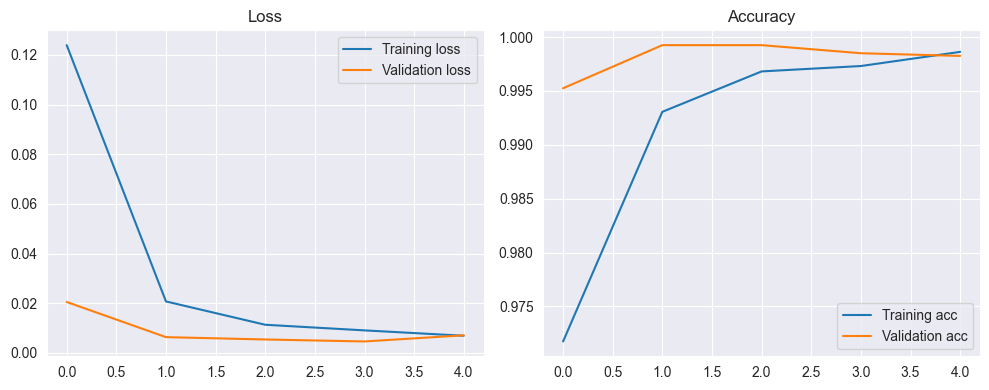

In [14]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_history_loss, label='Training loss')
plt.plot(val_history_loss, label='Validation loss')
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_history_acc, label='Training acc')
plt.plot(val_history_acc, label='Validation acc')
plt.legend(); plt.title("Accuracy")

plt.tight_layout()
plt.show()

Test accuracy: 0.9982


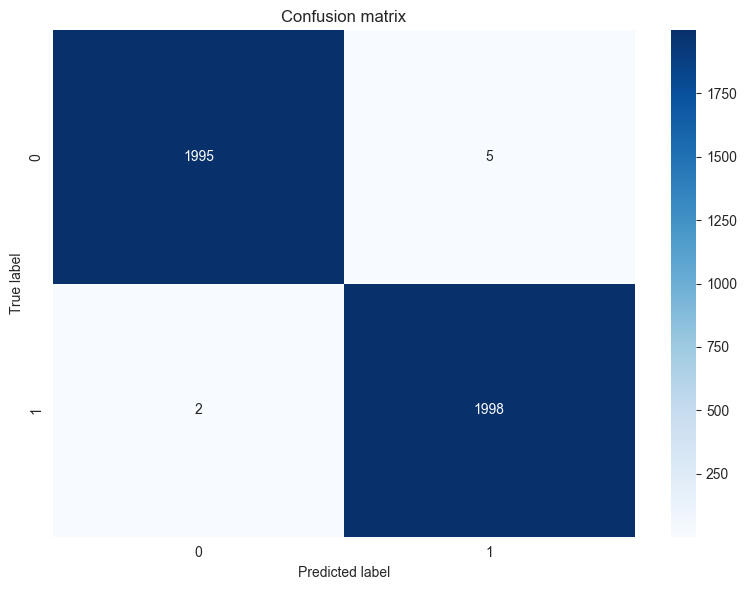

              precision    recall  f1-score   support

           0     0.9990    0.9975    0.9982      2000
           1     0.9975    0.9990    0.9983      2000

    accuracy                         0.9982      4000
   macro avg     0.9983    0.9983    0.9982      4000
weighted avg     0.9983    0.9982    0.9982      4000



In [15]:
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        out = model(xb)
        predictions = out.argmax(dim=1).cpu().numpy()
        labels = yb.cpu().numpy()
        all_predictions.append(predictions)
        all_labels.append(labels)

all_predictions = np.concatenate(all_predictions)
all_labels = np.concatenate(all_labels)

acc = accuracy_score(all_labels, all_predictions)
print(f"Test accuracy: {acc:.4f}")

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)

plt.title("Confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.grid(False) 
plt.tight_layout()
plt.show()

report = classification_report(all_labels, all_predictions, digits=4)
print(report)

In [16]:
with open('europarl-v7.es-en.en', 'r', encoding='utf-8') as f:
    en_texts = f.readlines()
with open('europarl-v7.es-en.es', 'r', encoding='utf-8') as f:
    es_texts = f.readlines()
    
data = pd.DataFrame({
    'text': en_texts + es_texts,
    'label': ['EN'] * len(en_texts) + ['ES'] * len(es_texts)
})

data = data.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"The shape of dataset: {len(data)} strings")
data.head()

The shape of dataset: 3931468 strings


,text,label
0,También creo que no solo deberíamos considerar...,ES
1,Ha venido siendo una característica permanente...,ES
2,A number of you raised the issue of traceabili...,EN
3,"This summit, though, about the enlargement str...",EN
4,La UE no debe dictar los marcos para las difer...,ES


In [17]:
stop_words_en = set(stopwords.words('english'))
stop_words_es = set(stopwords.words('spanish'))

def preprocess(text, lang):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    if lang == 'EN':
        words = [w for w in words if w not in stop_words_en]
    else:
        words = [w for w in words if w not in stop_words_es]
    return ' '.join(words)

data['clean_text'] = data.apply(lambda x: preprocess(x['text'], x['label']), axis=1)
data.head()

,text,label,clean_text
0,También creo que no solo deberíamos considerar...,ES,creo solo deberíamos considerar unidos sino ev...
1,Ha venido siendo una característica permanente...,ES,venido siendo característica permanente histor...
2,A number of you raised the issue of traceabili...,EN,number raised issue traceability indeed one ma...
3,"This summit, though, about the enlargement str...",EN,summit though enlargement strategy suddenly ta...
4,La UE no debe dictar los marcos para las difer...,ES,ue debe dictar marcos diferencias culturales p...


In [18]:
VOCABULARY_SIZE = 80000 
MAX_SENT_LEN = 60       

all_text = ' '.join(data['clean_text'].astype(str).tolist())
words = all_text.lower().split()
word_counts = Counter(words)

most_common = word_counts.most_common(VOCABULARY_SIZE - 2) 
vocabulary = {word: i+2 for i, (word, _) in enumerate(most_common)}
vocabulary['<PAD>'] = 0  
vocabulary['<UNK>'] = 1  

In [19]:
def text_to_indices(text, vocab, max_length):
    words = str(text).lower().split()
    indices = [vocab.get(w, vocab['<UNK>']) for w in words]

    if len(indices) < max_length:
        indices += [vocab['<PAD>']] * (max_length - len(indices))
    else:
        indices = indices[:max_length]
    return indices

X_indices = [text_to_indices(t, vocabulary, MAX_SENT_LEN) for t in data['clean_text']]
X_indices = np.array(X_indices)

label_map = {'EN': 0, 'ES': 1}
y_numeric = data['label'].map(label_map).values

print("Sample of text:", data['clean_text'][0])
print("Sample of indices:", X_indices[0])

Sample of text: creo solo deberíamos considerar unidos sino evolución china india
Sample of indices: [  61  231  732 1744  422   97 2446  488 1654    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]


In [20]:
BATCH_SIZE = 64
X_train, X_test, y_train, y_test = train_test_split(X_indices, y_numeric, test_size=0.2, random_state=42)

train_data = TensorDataset(torch.from_numpy(X_train).long(), torch.from_numpy(y_train).long())
test_data = TensorDataset(torch.from_numpy(X_test).long(), torch.from_numpy(y_test).long())
train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}; test batches: {len(test_loader)}")

Train batches: 49144; test batches: 12286


In [21]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pretrained_weights=None):
        super(LSTM, self).__init__()
        
        if pretrained_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_weights, freeze=False, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        

        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        return self.fc(hidden_cat)

In [22]:
def train_task3(model, train_loader, val_loader, criterion, optimizer, save_name, epochs=5):
    model = model.to(device)
    
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = correct / total
        
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        
        model.eval()
        val_running_loss = 0.0
        v_correct = 0
        v_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels) 
                
                val_running_loss += loss.item()
                preds = outputs.argmax(dim=1)
                v_correct += (preds == labels).sum().item()
                v_total += labels.size(0)
        
        epoch_val_loss = val_running_loss / len(val_loader)
        epoch_val_acc = v_correct / v_total
        
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)
        
        print(f'Epoch {epoch+1}/{epochs}')
        print(f'Training loss: {epoch_train_loss:.5f} ; training accuracy: {epoch_train_acc:.5f}')
        print(f'Validation loss: {epoch_val_loss:.5f} ; validation accuracy: {epoch_val_acc:.5f}')
    
    torch.save(model.state_dict(), os.path.join(OUT_DIR, f"{save_name}.pth"))
    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

In [23]:
EMBED_DIM = 50
HIDDEN_DIM = 64
EPOCHS = 5

model_a = LSTM(len(vocabulary), EMBED_DIM, HIDDEN_DIM, output_dim=2, pretrained_weights=None)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_a.parameters(), lr=0.001)

hist_a_train_loss, hist_a_train_acc, hist_a_val_loss, hist_a_val_acc = train_task3(
    model=model_a, 
    train_loader=train_loader, 
    val_loader=test_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    save_name='model_task3_a',
    epochs=EPOCHS
)

Epoch 1/5
Training loss: 0.01749 ; training accuracy: 0.99143
Validation loss: 0.00590 ; validation accuracy: 0.99629
Epoch 2/5
Training loss: 0.00625 ; training accuracy: 0.99610
Validation loss: 0.00554 ; validation accuracy: 0.99628
Epoch 3/5
Training loss: 0.00583 ; training accuracy: 0.99623
Validation loss: 0.00552 ; validation accuracy: 0.99630
Epoch 4/5
Training loss: 0.00563 ; training accuracy: 0.99629
Validation loss: 0.00549 ; validation accuracy: 0.99643
Epoch 5/5
Training loss: 0.00550 ; training accuracy: 0.99636
Validation loss: 0.00547 ; validation accuracy: 0.99644


In [24]:
def load_glove_matrix(vocab, embed_dim=50):
    glove_filename = f'glove.6B.{embed_dim}d.txt'

    embeddings_index = {}
    with open(glove_filename, encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    weights_matrix = np.zeros((len(vocab), embed_dim))
    hits = 0
    for word, i in vocab.items():
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            weights_matrix[i] = embedding_vector
            hits += 1
        else:
            weights_matrix[i] = np.random.normal(scale=0.6, size=(embed_dim, ))
            
    return torch.tensor(weights_matrix, dtype=torch.float32)

glove_weights = load_glove_matrix(vocabulary, EMBED_DIM)

In [25]:
model_b = LSTM(len(vocabulary), EMBED_DIM, HIDDEN_DIM, output_dim=2, pretrained_weights=glove_weights)
optimizer = optim.Adam(model_b.parameters(), lr=0.001)

hist_b_train_loss, hist_b_train_acc, hist_b_val_loss, hist_b_val_acc = train_task3(
    model=model_b, 
    train_loader=train_loader, 
    val_loader=test_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    save_name='model_task3_b',
    epochs=EPOCHS
)


Epoch 1/5
Training loss: 0.00771 ; training accuracy: 0.99568
Validation loss: 0.00551 ; validation accuracy: 0.99642
Epoch 2/5
Training loss: 0.00565 ; training accuracy: 0.99632
Validation loss: 0.00536 ; validation accuracy: 0.99636
Epoch 3/5
Training loss: 0.00545 ; training accuracy: 0.99639
Validation loss: 0.00534 ; validation accuracy: 0.99647
Epoch 4/5
Training loss: 0.00540 ; training accuracy: 0.99639
Validation loss: 0.00532 ; validation accuracy: 0.99651
Epoch 5/5
Training loss: 0.00535 ; training accuracy: 0.99638
Validation loss: 0.00535 ; validation accuracy: 0.99637


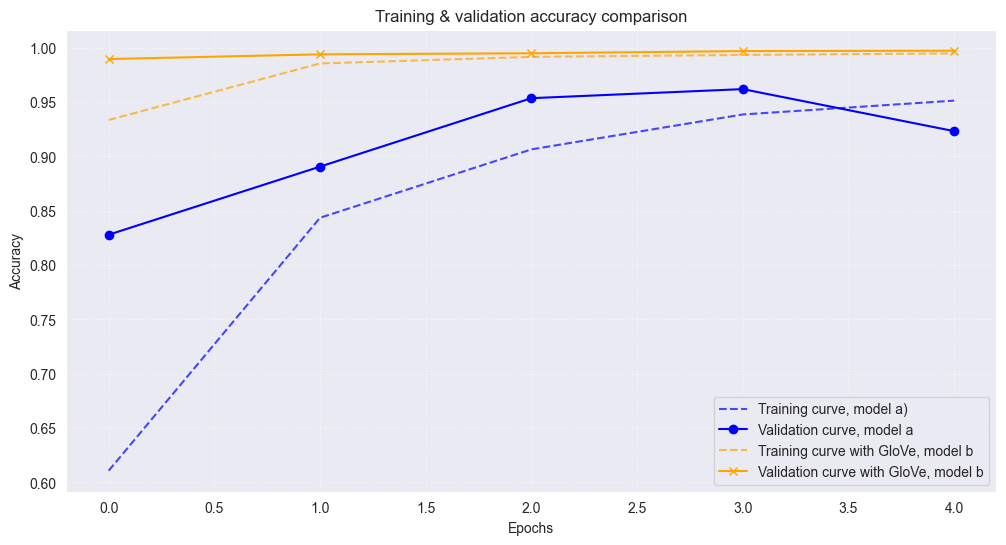

----- Model A  -----
Training accuracy: 0.95140
Validation accuracy:   0.92333

----- Model B  -----
Training accuracy: 0.99487
Validation accuracy:   0.99733


In [44]:
plt.figure(figsize=(12, 6))
plt.plot(hist_a_train_acc, label='Training curve, model a)', linestyle='--', color='blue', alpha=0.7)
plt.plot(hist_a_val_acc, label='Validation curve, model a', marker='o', color='blue')

plt.plot(hist_b_train_acc, label='Training curve with GloVe, model b', linestyle='--', color='orange', alpha=0.7)
plt.plot(hist_b_val_acc, label='Validation curve with GloVe, model b', marker='x', color='orange')

plt.title('Training & validation accuracy comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("----- Model A  -----")
print(f"Training accuracy: {hist_a_train_acc[-1]:.5f}")
print(f"Validation accuracy:   {hist_a_val_acc[-1]:.5f}")

print("\n----- Model B  -----")
print(f"Training accuracy: {hist_b_train_acc[-1]:.5f}")
print(f"Validation accuracy:   {hist_b_val_acc[-1]:.5f}")

In [27]:
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 0.001
data_dir = "Vegetable Images"
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'validation')

In [28]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [38]:
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes: {num_classes}")
print(class_names)


Classes: 15
['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


In [30]:
def train_task2(model, train_loader, val_loader, criterion, optimizer, save_name, num_epochs=5):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []
    
    print(f"Starting training for {num_epochs} epochs...")
    
    for epoch in range(num_epochs):
     
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            pbar.set_postfix({'loss': loss.item()})
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels) 
                
                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        
        epoch_val_loss = val_running_loss / val_total
        epoch_val_acc = val_correct / val_total
        
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)
        
       
        print(f'Training loss: {epoch_train_loss:.5f} ; training accuracy: {epoch_train_acc:.5f}')
        print(f'Validation loss: {epoch_val_loss:.5f} ; validation accuracy: {epoch_val_acc:.5f}')

    torch.save(model.state_dict(), os.path.join(OUT_DIR, f"{save_name}.pth"))
   

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

In [31]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
       
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [32]:
model_a = SimpleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_a = optim.Adam(model_a.parameters(), lr=LEARNING_RATE)

hist_a_train_loss, hist_a_train_acc, hist_a_val_loss, hist_a_val_acc = train_task2(
    model=model_a, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    optimizer=optimizer_a, 
    save_name='model_task2_a',
    num_epochs=EPOCHS
)

Starting training for 5 epochs...


Epoch 1/5: 100%|██████████| 469/469 [01:23<00:00,  5.59batch/s, loss=0.856]


Training loss: 1.19437 ; training accuracy: 0.61080
Validation loss: 0.52058 ; validation accuracy: 0.82800


Epoch 2/5: 100%|██████████| 469/469 [00:44<00:00, 10.63batch/s, loss=0.318]


Training loss: 0.48302 ; training accuracy: 0.84360
Validation loss: 0.35376 ; validation accuracy: 0.89067


...

Training loss: 0.29791 ; training accuracy: 0.90653
Validation loss: 0.16056 ; validation accuracy: 0.95367


Epoch 4/5: 100%|██████████| 469/469 [00:43<00:00, 10.67batch/s, loss=0.184]  


Training loss: 0.20341 ; training accuracy: 0.93867
Validation loss: 0.13140 ; validation accuracy: 0.96200


Epoch 5/5: 100%|██████████| 469/469 [00:43<00:00, 10.68batch/s, loss=0.588]  


Training loss: 0.16557 ; training accuracy: 0.95140
Validation loss: 0.24768 ; validation accuracy: 0.92333


In [33]:
model_b = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

for param in model_b.features.parameters():
    param.requires_grad = False

in_features = model_b.classifier[1].in_features
model_b.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, num_classes)
)

model_b = model_b.to(device)

optimizer_b = optim.Adam(model_b.classifier.parameters(), lr=LEARNING_RATE)

hist_b_train_loss, hist_b_train_acc, hist_b_val_loss, hist_b_val_acc = train_task2(
    model=model_b, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    optimizer=optimizer_b, 
    save_name='model_task2_b',
    num_epochs=EPOCHS
)

Starting training for 5 epochs...


Epoch 1/5: 100%|██████████| 469/469 [00:30<00:00, 15.52batch/s, loss=0.147] 


Training loss: 0.47261 ; training accuracy: 0.93360
Validation loss: 0.10059 ; validation accuracy: 0.98967


Epoch 2/5: 100%|██████████| 469/469 [00:30<00:00, 15.57batch/s, loss=0.128] 


Training loss: 0.09989 ; training accuracy: 0.98560
Validation loss: 0.04717 ; validation accuracy: 0.99400


...

Training loss: 0.05933 ; training accuracy: 0.99167
Validation loss: 0.03321 ; validation accuracy: 0.99500


Epoch 4/5: 100%|██████████| 469/469 [00:30<00:00, 15.21batch/s, loss=0.0298] 


Training loss: 0.04510 ; training accuracy: 0.99347
Validation loss: 0.02312 ; validation accuracy: 0.99700


Epoch 5/5: 100%|██████████| 469/469 [01:55<00:00,  4.07batch/s, loss=0.014]  


Training loss: 0.03231 ; training accuracy: 0.99487
Validation loss: 0.01908 ; validation accuracy: 0.99733


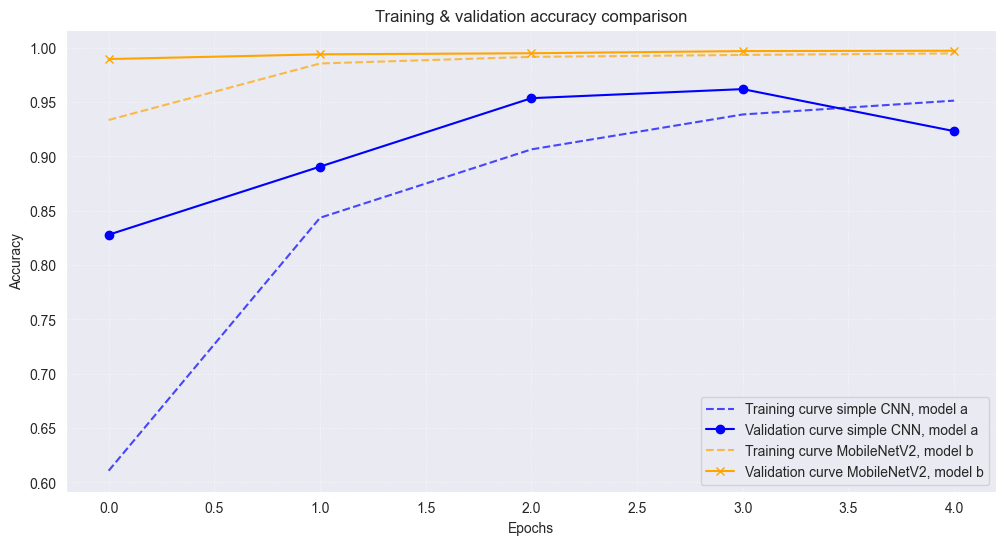

----- Model A -----
Training accuracy:   0.95140
Validation accuracy: 0.92333

----- Model B -----
Training accuracy:   0.99487
Validation accuracy: 0.99733


In [34]:
plt.figure(figsize=(12, 6))

plt.plot(hist_a_train_acc, label='Training curve simple CNN, model a', linestyle='--', color='blue', alpha=0.7)
plt.plot(hist_a_val_acc, label='Validation curve simple CNN, model a', marker='o', color='blue')

plt.plot(hist_b_train_acc, label='Training curve MobileNetV2, model b', linestyle='--', color='orange', alpha=0.7)
plt.plot(hist_b_val_acc, label='Validation curve MobileNetV2, model b', marker='x', color='orange')

plt.title('Training & validation accuracy comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("----- Model A -----")
print(f"Training accuracy:   {hist_a_train_acc[-1]:.5f}")
print(f"Validation accuracy: {hist_a_val_acc[-1]:.5f}")

print("\n----- Model B -----")
print(f"Training accuracy:   {hist_b_train_acc[-1]:.5f}")
print(f"Validation accuracy: {hist_b_val_acc[-1]:.5f}")

In [41]:
def visualize_model_predictions(model, loader, class_names, model_name, num_images=9):
    model.eval()
    images_shown = 0
    
    images, labels = next(iter(loader)) 
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
    plt.figure(figsize=(12, 12))
    plt.suptitle(f"Predictions for: {model_name}", fontsize=16, y=0.95)
    
    for i in range(num_images):
        ax = plt.subplot(3, 3, i + 1)
        
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        
    
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        
        predicted_label = class_names[preds[i]]
        true_label = class_names[labels[i]]
        
        color = 'green' if predicted_label == true_label else 'red'
        
        ax.set_title(f"P: {predicted_label}\nT: {true_label}", color=color, fontsize=10, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

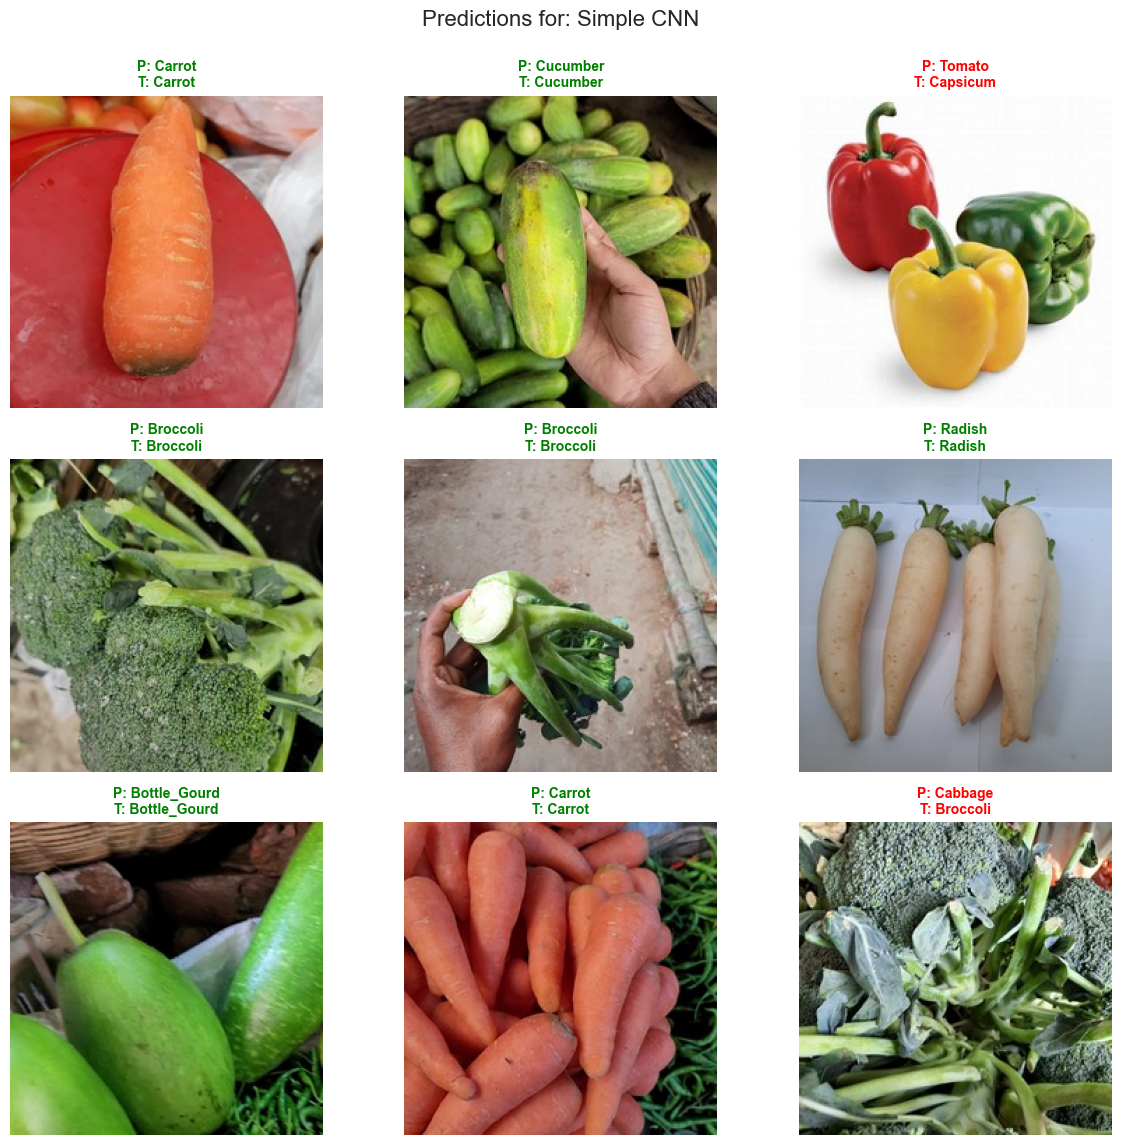

In [42]:
model_a.load_state_dict(torch.load(os.path.join(OUT_DIR, "model_task2_a.pth")))

visualize_model_predictions(
    model_a, 
    val_loader, 
    class_names, 
    model_name="Simple CNN",
    num_images=9
)

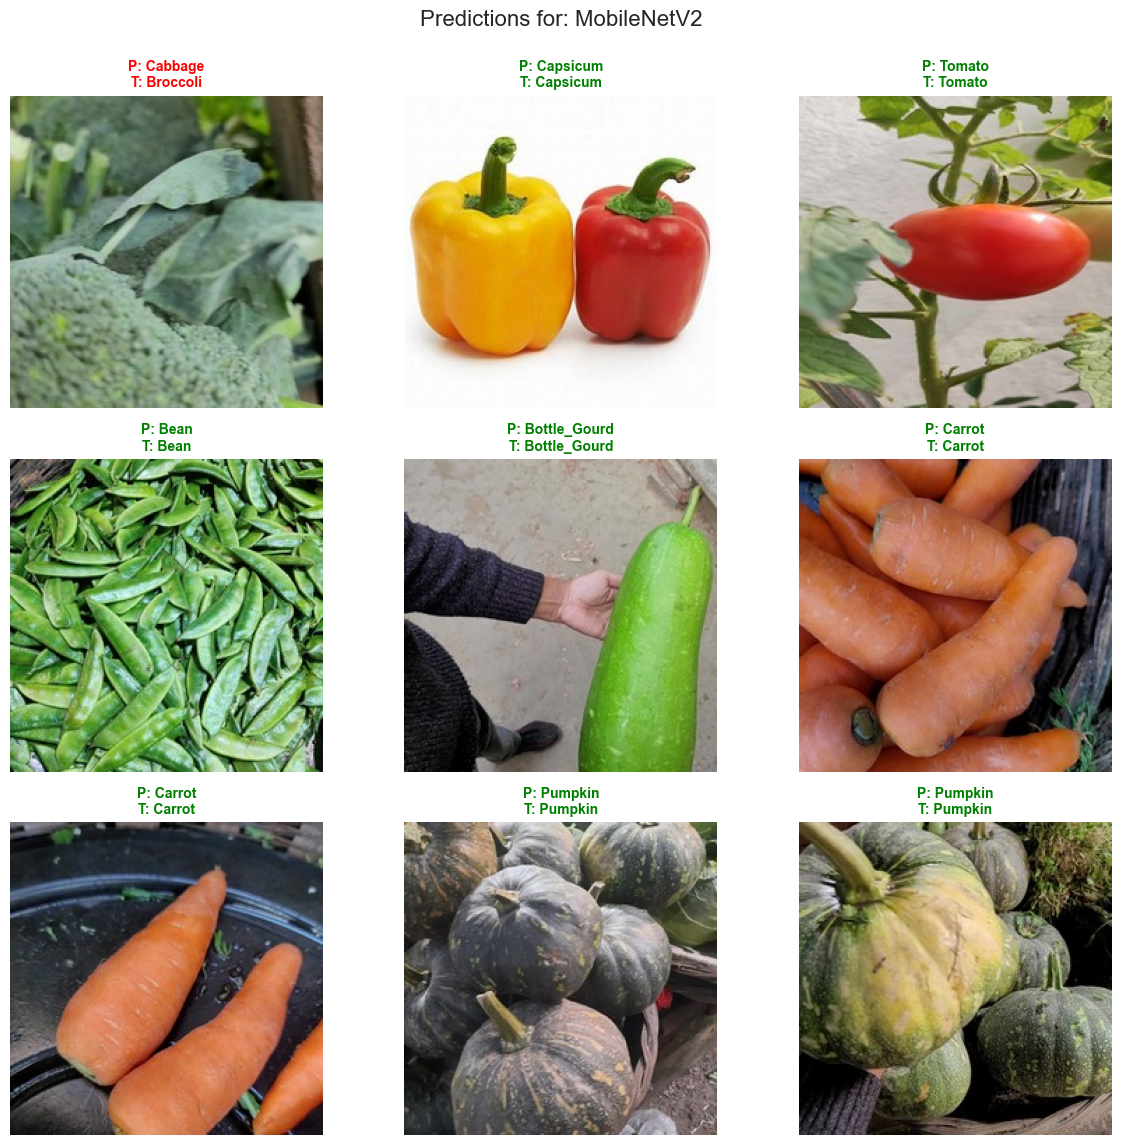

In [43]:
model_b.load_state_dict(torch.load(os.path.join(OUT_DIR, "model_task2_b.pth")))

visualize_model_predictions(
    model_b, 
    val_loader, 
    class_names, 
    model_name="MobileNetV2",
    num_images=9
)